# Global Economic Data Visualization

Analyze GDP, population, and inflation across 50 countries using Python, Pandas, NumPy, and Matplotlib.

**Data source:** World Bank World Development Indicators. The World Bank Indicators API supports programmatic access to indicator data. citeturn0search0turn0search2


## 1. Import libraries


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


## 2. Load data

We use three World Bank indicators:
- GDP (current US$): `NY.GDP.MKTP.CD`
- Population, total: `SP.POP.TOTL`
- Inflation, consumer prices (annual %): `FP.CPI.TOTL.ZG`

The API supports multiple indicators in one request and JSON output. citeturn0search1turn0search2


In [5]:
year = 2024
url = (
    'https://api.worldbank.org/v2/country/all/indicator/'
    'NY.GDP.MKTP.CD;SP.POP.TOTL;FP.CPI.TOTL.ZG'
    f'?date={year}&format=json&per_page=1000'
)

raw = pd.read_json(url)
raw.head()


,message
0,"[{'id': '120', 'key': 'Invalid value', 'value'..."


## 3. Convert the API response into a clean table


In [7]:
import requests
import pandas as pd

year = 2024

def get_indicator(indicator_code, value_name):
    url = (
        f"https://api.worldbank.org/v2/country/all/"
        f"indicator/{indicator_code}"
        f"?date={year}&format=json&per_page=1000"
    )
    
    response = requests.get(url)
    data = response.json()

    # World Bank API stores observations in data[1]
    records = data[1]

    rows = []

    for item in records:
        rows.append({
            "countryiso3code": item["countryiso3code"],
            "country": item["country"]["value"],
            value_name: item["value"]
        })

    return pd.DataFrame(rows)


# Get the three indicators
gdp = get_indicator(
    "NY.GDP.MKTP.CD",
    "GDP"
)

population = get_indicator(
    "SP.POP.TOTL",
    "Population"
)

inflation = get_indicator(
    "FP.CPI.TOTL.ZG",
    "Inflation"
)


# Merge the datasets
df = gdp.merge(
    population,
    on=["countryiso3code", "country"],
    how="inner"
)

df = df.merge(
    inflation,
    on=["countryiso3code", "country"],
    how="inner"
)


# Remove missing values
df = df.dropna(
    subset=["GDP", "Population", "Inflation"]
)


# Keep only actual countries
df = df[
    df["countryiso3code"].notna()
].copy()


# Select 50 countries
df = df.sort_values("country").head(50).reset_index(drop=True)


print("Number of countries:", len(df))

df.head(10)

Number of countries: 50


,countryiso3code,country,GDP,Population,Inflation
0,AFG,Afghanistan,1.777851e+10,42647492.0,-6.601186
1,AFE,Africa Eastern and Southern,1.252564e+12,769280888.0,4.770857
2,AFW,Africa Western and Central,7.373670e+11,520655398.0,3.608044
3,ALB,Albania,2.703747e+10,2377128.0,2.215874
4,DZA,Algeria,2.693223e+11,46814308.0,4.046115
5,AGO,Angola,1.030805e+11,37885849.0,28.240495
6,ATG,Antigua and Barbuda,2.162367e+09,93772.0,6.198867
7,ARB,Arab World,3.745044e+12,492612632.0,2.308901
8,ARG,Argentina,6.383655e+11,45696159.0,219.883929
9,ARM,Armenia,2.595528e+10,3033500.0,0.269512


## 4. Basic data inspection


In [8]:
print('Rows:', len(df))
print('\nMissing values:')
print(df.isnull().sum())

df.describe()


Rows: 50

Missing values:
countryiso3code    0
country            0
GDP                0
Population         0
Inflation          0
dtype: int64


,GDP,Population,Inflation
count,5.000000e+01,5.000000e+01,50.000000
mean,7.686892e+11,8.519230e+07,8.035241
std,2.705132e+12,2.403477e+08,30.974947
min,6.888815e+08,6.620500e+04,-6.601186
25%,1.631923e+10,2.413131e+06,1.558060
50%,6.465366e+10,1.055393e+07,2.789834
75%,4.235195e+11,3.639794e+07,4.350008
max,1.872967e+13,1.408975e+09,219.883929


## 5. Visualization 1 — GDP by country


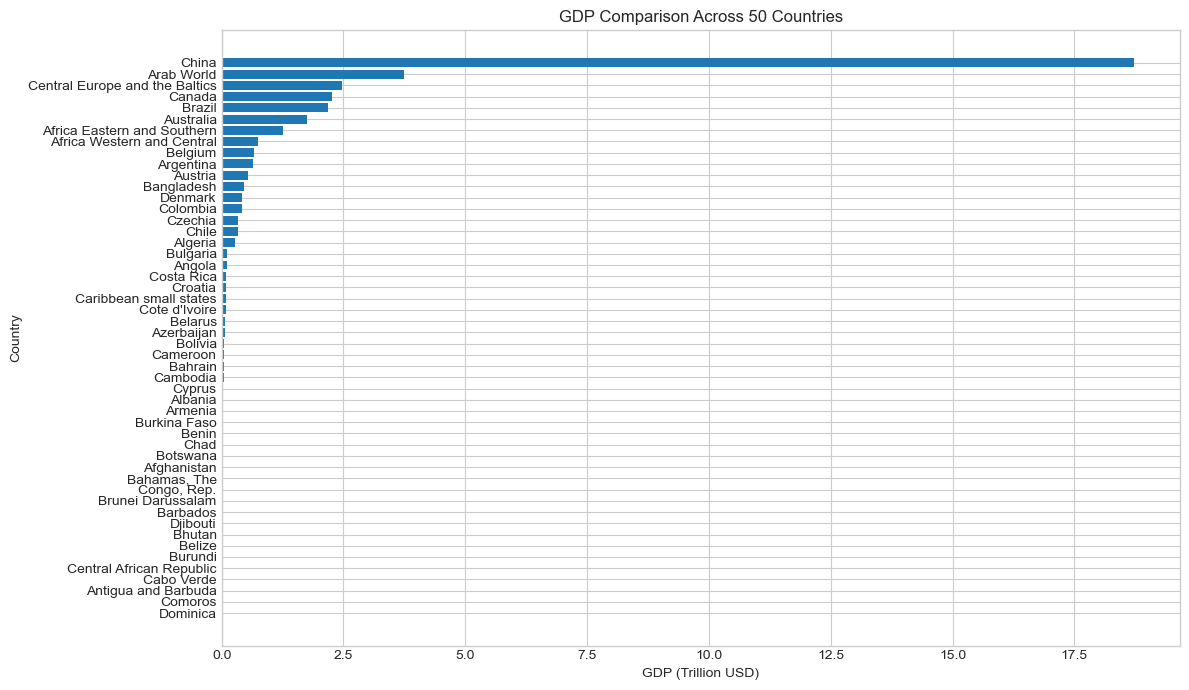

In [9]:
plot_df = df.sort_values('GDP', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(plot_df['country'], plot_df['GDP'] / 1e12)
plt.gca().invert_yaxis()
plt.xlabel('GDP (Trillion USD)')
plt.ylabel('Country')
plt.title('GDP Comparison Across 50 Countries')
plt.tight_layout()
plt.show()


## 6. Visualization 2 — Population by country


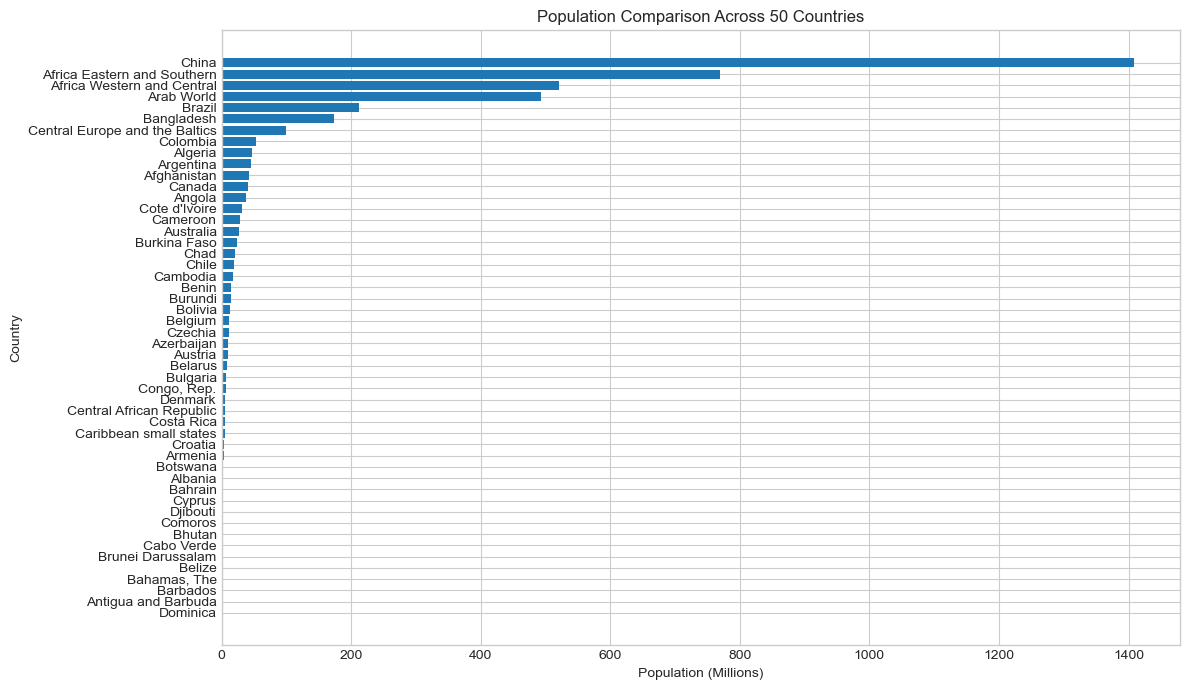

In [10]:
plot_df = df.sort_values('Population', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(plot_df['country'], plot_df['Population'] / 1e6)
plt.gca().invert_yaxis()
plt.xlabel('Population (Millions)')
plt.ylabel('Country')
plt.title('Population Comparison Across 50 Countries')
plt.tight_layout()
plt.show()


## 7. Visualization 3 — GDP vs Population


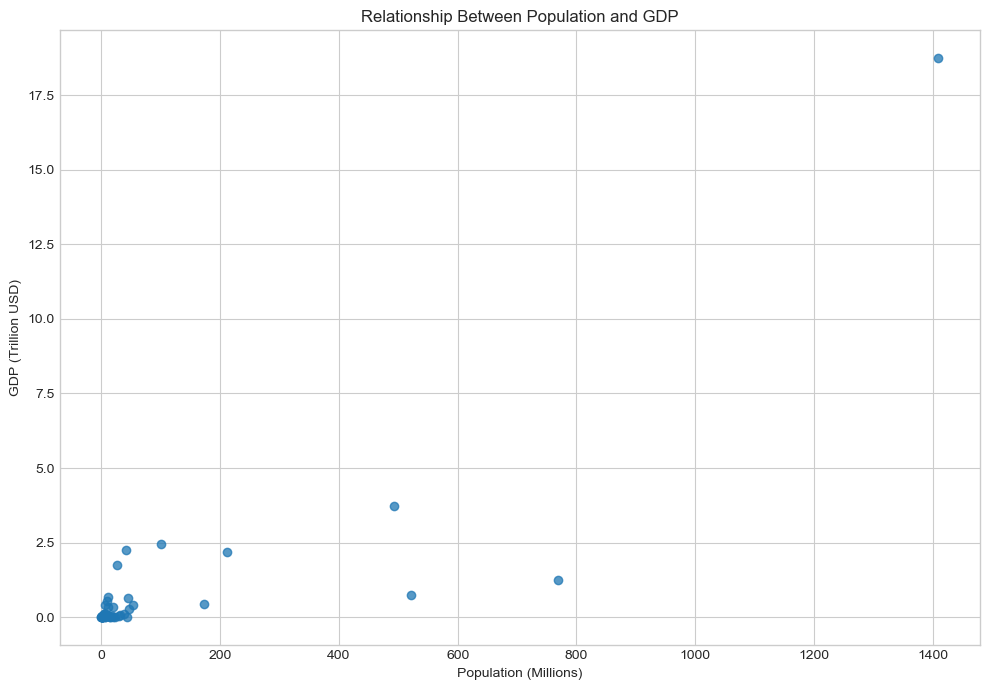

In [11]:
plt.figure(figsize=(10, 7))
plt.scatter(df['Population'] / 1e6, df['GDP'] / 1e12, alpha=0.75)
plt.xlabel('Population (Millions)')
plt.ylabel('GDP (Trillion USD)')
plt.title('Relationship Between Population and GDP')
plt.tight_layout()
plt.show()


## 8. Visualization 4 — Inflation by country


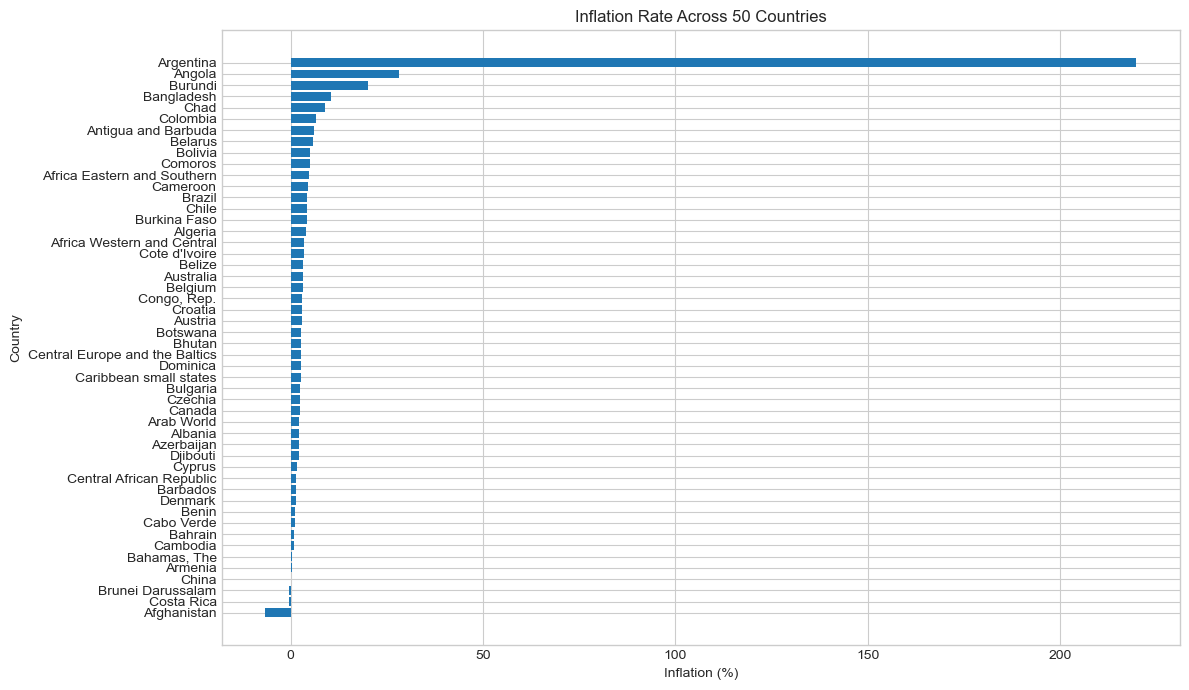

In [12]:
plot_df = df.sort_values('Inflation', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(plot_df['country'], plot_df['Inflation'])
plt.gca().invert_yaxis()
plt.xlabel('Inflation (%)')
plt.ylabel('Country')
plt.title('Inflation Rate Across 50 Countries')
plt.tight_layout()
plt.show()


## 9. Visualization 5 — Correlation heatmap

This project intentionally uses Matplotlib only. The correlation matrix is displayed as an image with annotations.


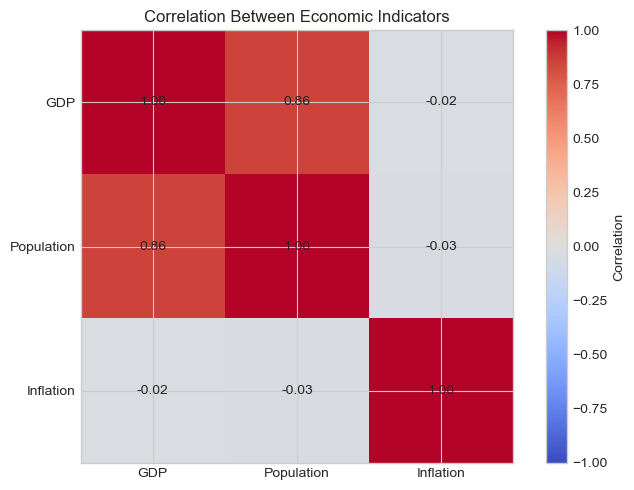

In [13]:
corr = df[['GDP', 'Population', 'Inflation']].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Between Economic Indicators')

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.tight_layout()
plt.show()


## 10. Key insights

Run the following cells to generate evidence-based observations rather than manually guessing them.


In [14]:
top_gdp = df.nlargest(5, 'GDP')[['country','GDP']]
top_population = df.nlargest(5, 'Population')[['country','Population']]
highest_inflation = df.nlargest(5, 'Inflation')[['country','Inflation']]
lowest_inflation = df.nsmallest(5, 'Inflation')[['country','Inflation']]

print('Top 5 countries by GDP:')
display(top_gdp)

print('Top 5 countries by population:')
display(top_population)

print('Highest inflation rates:')
display(highest_inflation)

print('Lowest inflation rates:')
display(lowest_inflation)

print('Correlation matrix:')
display(corr)


Top 5 countries by GDP:


,country,GDP
38,China,1.872967e+13
7,Arab World,3.745044e+12
35,Central Europe and the Baltics,2.463135e+12
32,Canada,2.270076e+12
24,Brazil,2.185822e+12


Top 5 countries by population:


,country,Population
38,China,1.408975e+09
1,Africa Eastern and Southern,7.692809e+08
2,Africa Western and Central,5.206554e+08
7,Arab World,4.926126e+08
24,Brazil,2.119986e+08


Highest inflation rates:


,country,Inflation
8,Argentina,219.883929
5,Angola,28.240495
28,Burundi,20.212493
15,Bangladesh,10.465748
36,Chad,8.899507


Lowest inflation rates:


,country,Inflation
0,Afghanistan,-6.601186
42,Costa Rica,-0.412853
25,Brunei Darussalam,-0.388674
38,China,0.218129
9,Armenia,0.269512


Correlation matrix:


,GDP,Population,Inflation
GDP,1.000000,0.858251,-0.024097
Population,0.858251,1.000000,-0.031257
Inflation,-0.024097,-0.031257,1.000000
